This notebook will create the basic "counting and types" figure which also will show the plot-type accuracy plots.

In [2]:
main_llm_dir = '/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/'

# low-tier
low_dirs_to_use = ['chatgpt_api/', 'gemini/', 'claude_haiku/']

# mid-to-high tier
midHigh_dirs_to_use = ['chatgpt_api_highR_lowVerbose/', 'claude_haiku_thinking_maxT8000/', 'chatgpt_api_highR_lowVerbose_mini/']


# full baseline data stored
dir_jsons = '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/qa_jsons/'

save_fig_dir = '/Users/jnaiman/Dropbox/jcdl_followup/paper_figures/'

replace_names = {'chatgpt_api':'ChatGPT', 
                        'chatgpt_api_highR_lowVerbose':'ChatGPT-HR',
                        #'chatgpt_api_highR_lowVerbose_mini':'ChatGPT-HR-mini', 
                        'chatgpt_api_highR_lowVerbose_mini':'ChatGPT-HRM', 
                        'gemini':'Gemini', 
                        'claude_haiku':'Claude', 
                        'claude_haiku_thinking':'Claude-T1',
                        'claude_haiku_thinking_maxT8000':'Claude-T'
                        }

In [4]:
from sys import path
path.append('../')

import matplotlib.pyplot as plt
from importlib import reload
from copy import deepcopy
import numpy as np
import pandas as pd
import seaborn as sns
import fastwer

import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks

reload(utils.results_plotting_utils)
from utils.results_plotting_utils import add_kde_contours
from utils.parse_lmm_output_utils import get_lmm_gt


dirs_to_use = deepcopy(low_dirs_to_use)
dirs_to_use.extend(midHigh_dirs_to_use)

In [5]:
def make_question_tags():
    df_question_tags = {}
    for t in ['tag', 'question', 'Level', 'Type']:
        df_question_tags[t] = []
    return df_question_tags



In [6]:
import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import get_dirs_names_files

dirnames, dirs, files_parsed = get_dirs_names_files(main_llm_dir, 
        dirs_to_use, 
        replace_names = replace_names,
        verbose=True)

DIRS:
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet_maxtoken8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_mini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_old
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking_maxT8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose_mini

ONLY USED DIRNAMES, DIRS
ChatGPT ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api/
Gemini ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini/
Claude ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_h

In [7]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import parse_json_files, fix_aspect

df = parse_json_files(dirnames, dirs, files_parsed, dir_jsons, 
                     verbose=False, use_explanation=True)
print("!!!!!!!! DONE LOADING !!!!!!!!!!!")

[ERROR]: different types of values, could not fix:
  GT: 4.561426392275432 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: -60.00537889895291 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -59.60426621286831 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERROR]: different types of values, could not fix:
  GT: 20.525898080144625 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 19416132.33937408 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 3.715940908874518 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 105.2835618283954 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ER

<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'
<unknown>:1: SyntaxWarning: invalid escape sequence '\c'


[ERROR]: different types of values, could not fix:
  GT: 14140.95893731211 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 14.097384175999514 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 17520347215890.066 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 4361323308289.718 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -9.285323670614062 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 116.44542286828813 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: -12.311367476438452 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERR

<unknown>:1: SyntaxWarning: invalid escape sequence '\d'


[ERROR]: different types of values, could not fix:
  GT: 9.125101272202379 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 3.520516044447898 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -1.1527183205458629 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 5.947112573647658 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 1491423.8486516487 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 213328.4338576842 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 135.0703267885132 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""

...

[ERROR]: different types of values, could not fix:
  GT: 1385.3350403983563 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 5.572388681886037 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -263.69179358271674 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERROR]: different types of values, could not fix:
  GT: 112.86780638500066 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: -6.402638216002607 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 5.534922356901159 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}



<unknown>:1: SyntaxWarning: invalid escape sequence '\P'
<unknown>:1: SyntaxWarning: invalid escape sequence '\D'
<unknown>:1: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: invalid escape sequence '\p'
<unknown>:2: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\O'
<unknown>:4: SyntaxWarning: invalid escape sequence '\s'
<unknown>:2: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: inv

[ERROR]: different types of values, could not fix:
  GT: 130.54067743578003 <class 'float'>
  LLM: Unable to determine <class 'str'>
  raw LLM: {"mean color": "Unable to determine"}



<unknown>:3: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2: SyntaxWarning: invalid escape sequence '\o'


[ERROR]: different types of values, could not fix:
  GT: -249349.01704986204 <class 'float'>
  LLM: Unable to determine from visible labels <class 'str'>
  raw LLM: {"maximum color": "Unable to determine from visible labels"}

[ERROR]: different types of values, could not fix:
  GT: -513215.2147431419 <class 'float'>
  LLM: null <class 'str'>
  raw LLM: {"mean color": "null"}

[ERROR]: different types of values, could not fix:
  GT: -857456.5832552586 <class 'float'>
  LLM: Unable to determine from image <class 'str'>
  raw LLM: {"minimum color": "Unable to determine from image"}

!!!!!!!! DONE LOADING !!!!!!!!!!!


In [8]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type,Explanation
0,Picture_000167_qa,NaN,None,How many panels are in this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,"{'nrows': 1, 'ncols': 2}","{'nrows': 1, 'ncols': 2}",Level 1,Figure-level questions,{'explanation': 'The figure is split into two ...
1,Picture_000167_qa,NaN,None,What is the plot style used in this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'plot style': 'ggplot'},{'plot style': 'tableau-colorblind10'},Level 1,Figure-level questions,{'explanation': 'The figure uses a light gray ...
2,Picture_000167_qa,NaN,None,What is the colormap that was used in this fig...,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'colormap': 'PuOr'},{'colormap': 'vanimo'},Level 1,Figure-level questions,{'explanation': 'The right-hand heatmap uses a...
3,Picture_000167_qa,NaN,None,What is the aspect ratio of this figure?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'aspect ratio': 2.2},{'aspect ratio': 1.1308323730724412},Level 1,Figure-level questions,{'explanation': 'The image width is about 2048...
4,Picture_000167_qa,NaN,None,What are the titles for each figure panel?,False,ChatGPT,gpt-5.4-nano-2026-03-17,{'titles': ['Unit 20\u201c \u2264 r \u2264 60\...,{'titles': ['Unit $\rm 20''\leq r \leq 60''$ ...,Level 1,Figure-level questions,{'explanation': 'The left panel has a visible ...


In [9]:
# questions_figure_plots = [
#     {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'color-mean data','question':'What is the mean value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'y-med data','question':'What is the median value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'color-med data','question':'What is the median value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
# ]

In [10]:
plot_types = df[~df['plot type'].isin([None])]['plot type'].unique()
plot_types

array(['contour', 'line', 'histogram', 'scatter'], dtype=object)

In [11]:
# get low/high subsets
low_models = []
high_models = []
for k,v in replace_names.items():
    if k+'/' in low_dirs_to_use:
        low_models.append(v)
    elif k+'/' in midHigh_dirs_to_use:
        high_models.append(v)
low_models, high_models

(['ChatGPT', 'Gemini', 'Claude'], ['ChatGPT-HR', 'ChatGPT-HRM', 'Claude-T'])

In [12]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks, add_kde_contours, make_square_grid_figure_gs

#marker_sizes, marker_styles, colors, labels = create_output_marks(df, marker_min=20, marker_max=70)
# markers
colors_levels_low = ['darkblue', 'orange', 'cyan']
marker_sizes_low, marker_styles_low, \
    colors_low, labels_low = create_output_marks(df[df['model'].isin(low_models)], 
    marker_min=20, marker_max=70, 
    colors_levels=colors_levels_low)

colors_levels_high = ['red', 'gold', 'magenta']
marker_sizes_high, marker_styles_high, \
    colors_high, labels_high = create_output_marks(df[df['model'].isin(high_models)], 
    marker_min=20, marker_max=70, 
    colors_levels=colors_levels_high)

  the number of NaNs for model ChatGPT = 11
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 4
  the number of NaNs for model ChatGPT = 38
  the number of NaNs for model Gemini = 6
  the number of NaNs for model Claude = 17
  the number of NaNs for model ChatGPT = 16
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 1
  the number of NaNs for model ChatGPT = 7
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 11
  the number of NaNs for model ChatGPT-HR = 9
  the number of NaNs for model Claude-T = 4
  the number of NaNs for model ChatGPT-HRM = 2
  the number of NaNs for model ChatGPT-HR = 30
  the number of NaNs for model Claude-T = 21
  the number of NaNs for model ChatGPT-HRM = 17
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model ChatGPT-HRM = 0
  the number of NaNs for model ChatGPT-HR = 6
  the number of NaNs for mo

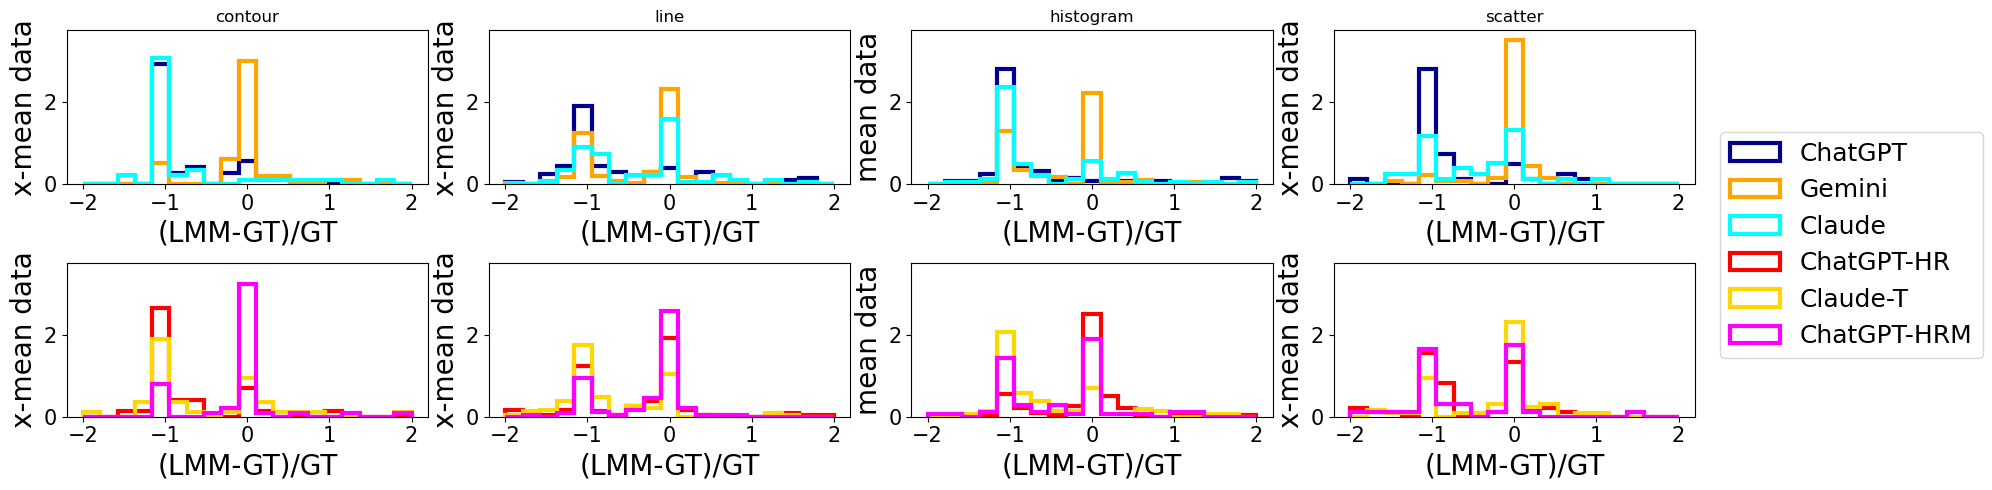

In [16]:
base = 5


fig, axes = plt.subplots(2, len(plot_types), figsize = (base*len(plot_types), base))

q = {}
q['line'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['scatter'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['contour'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['histogram'] = {'tag':'mean data','question':'What is the mean value of the data in this figure panel?', 'type':'float',  'norm':'diff'} # different!

take_abs = False
hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3
fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

ylim = (0,3.75)


# At the top, before the loop, initialize collectors
legend_handles = {}
legend_labels_map = {}

for imodeltype,(modeltypes,labels,colors) in enumerate(zip([low_dirs_to_use,midHigh_dirs_to_use],
                                                        [labels_low,labels_high],
                                                        [colors_low,colors_high])):
    #hasHistLegend = False

    for iplot,ptype in enumerate(plot_types):

        model_names = []
        for k,v in replace_names.items():
            if k + '/' in modeltypes:
                model_names.append(v)
        #print(model_names)
        dfsub = df[(df['model'].isin(model_names)) & (df['plot type']==ptype) & (df['question']==q[ptype]['question'])]
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            gt, lmm1 = get_lmm_gt(dfsub2, q[ptype]['type'],verbose=False)
            gttag = q[ptype]['tag']+' GT'
            lmtag = labels[model]
            lmm = deepcopy(lmm1)
            lmtag_adder = ''
            diffnorm = False
            if 'norm' in q[ptype]:
                if 'diff':
                    if take_abs:
                        lmm = (lmm-gt)/np.abs(gt)
                        lmtag_adder = '(LMM-GT)/|GT|'
                    else:
                        lmm = (lmm-gt)/gt
                        lmtag_adder = '(LMM-GT)/GT'

                    diffnorm = True
            dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
            diff = dfplot[lmtag]
            # count NaNs
            print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
            # axes[imodeltype][iplot].hist(diff, density=True, bins=hist_bins, label=labels[model], 
            #             color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
            #             linewidth=hist_thick)            
            axes[imodeltype][iplot].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                        color=colors[model], edgecolor=colors[model], 
                        linewidth=hist_thick, histtype='step')
            axes[imodeltype][iplot].set_xlabel(lmtag_adder, fontsize=fontsize)
            axes[imodeltype][iplot].set_ylabel(q[ptype]['tag'],  fontsize=fontsize)
            # if not hasHistLegend:
            #     axes[imodeltype][iplot].legend()
                #hasHistLegend = True
            axes[0][iplot].set_title(ptype)
            # Inside the inner loop, replace the legend block with:
            # (remove the hasHistLegend logic entirely)
            h, l = axes[imodeltype][iplot].get_legend_handles_labels()
            for handle, label in zip(h, l):
                if label not in legend_labels_map:
                    legend_handles[label] = handle
                    legend_labels_map[label] = label

# set font sizes
for ax in axes.flatten():
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_ylim(ylim)
    # legend = ax.get_legend()
    # if legend is not None:
    #     # Set legend font size for second subplot
    #     ax.legend(fontsize=legend_fontsize)

# Remove any per-axis legends that may have been set
for ax in axes.flatten():
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Build ordered handles/labels
all_handles = list(legend_handles.values())
all_labels = list(legend_labels_map.keys())

fig.legend(all_handles, all_labels,
           loc='center right',
           fontsize=legend_fontsize,
           bbox_to_anchor=(1.0, 0.5))


# Make room for the legend on the right
fig.tight_layout()
fig.subplots_adjust(right=0.85)  # adjust this value based on legend width
absadd = ''
if not take_abs:
    absadd += '_noabs'
fig.savefig(save_fig_dir + 'mean_per_model_type'+absadd+'.pdf')

## Also try with median

  the number of NaNs for model ChatGPT = 1
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 1
  the number of NaNs for model ChatGPT = 11
  the number of NaNs for model Gemini = 44
  the number of NaNs for model Claude = 13
  the number of NaNs for model ChatGPT = 0
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 11
  the number of NaNs for model ChatGPT = 1
  the number of NaNs for model Gemini = 1
  the number of NaNs for model Claude = 5
  the number of NaNs for model ChatGPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model ChatGPT-HRM = 0
  the number of NaNs for model ChatGPT-HR = 15
  the number of NaNs for model Claude-T = 43
  the number of NaNs for model ChatGPT-HRM = 50
  the number of NaNs for model ChatGPT-HR = 3
  the number of NaNs for model Claude-T = 2
  the number of NaNs for model ChatGPT-HRM = 2
  the number of NaNs for model ChatGPT-HR = 2
  the number of NaNs for mod

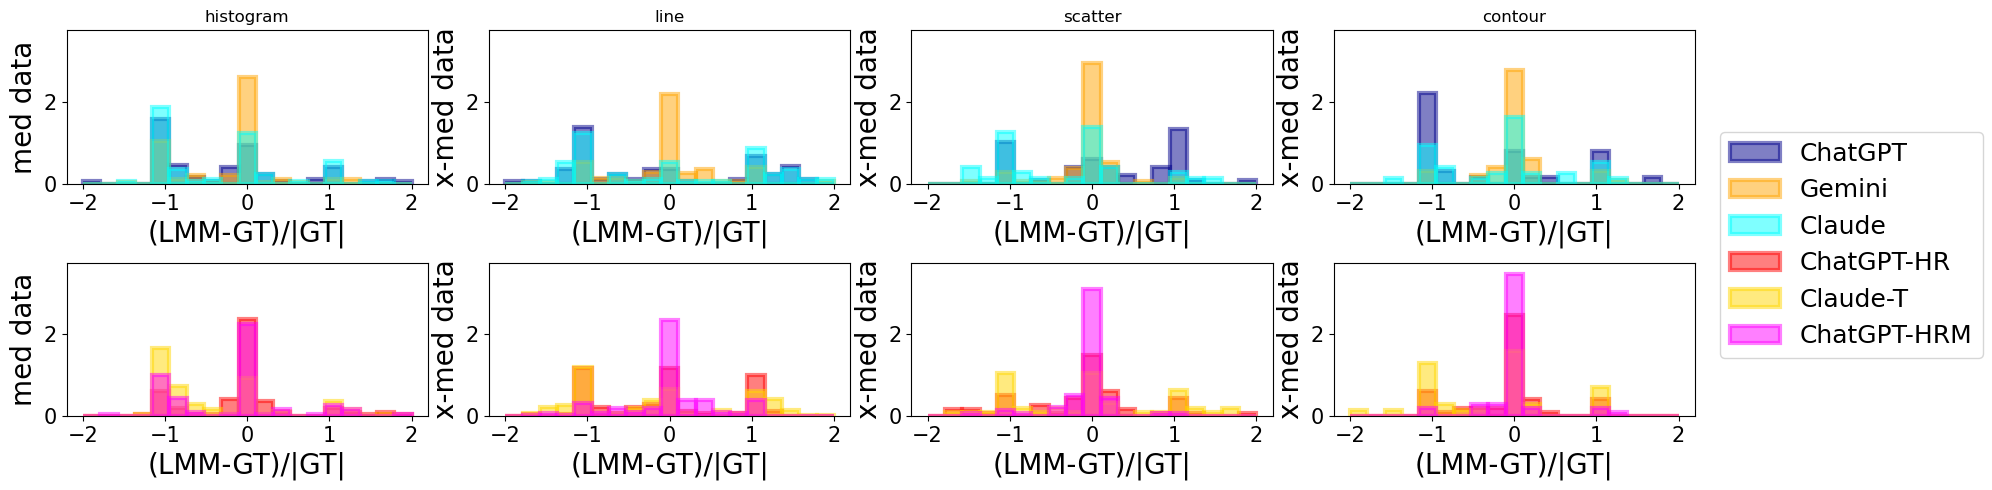

In [ ]:
base = 5


fig, axes = plt.subplots(2, len(plot_types), figsize = (base*len(plot_types), base))

q = {}
q['line'] = {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['scatter'] = {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['contour'] = {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['histogram'] = {'tag':'med data','question':'What is the median value of the data in this figure panel?', 'type':'float',  'norm':'diff'} # different!

take_abs = True
hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3
fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

ylim = (0,3.75)


# At the top, before the loop, initialize collectors
legend_handles = {}
legend_labels_map = {}

for imodeltype,(modeltypes,labels,colors) in enumerate(zip([low_dirs_to_use,midHigh_dirs_to_use],
                                                        [labels_low,labels_high],
                                                        [colors_low,colors_high])):
    #hasHistLegend = False

    for iplot,ptype in enumerate(plot_types):

        model_names = []
        for k,v in replace_names.items():
            if k + '/' in modeltypes:
                model_names.append(v)
        #print(model_names)
        dfsub = df[(df['model'].isin(model_names)) & (df['plot type']==ptype) & (df['question']==q[ptype]['question'])]
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            gt, lmm1 = get_lmm_gt(dfsub2, q[ptype]['type'],verbose=False)
            gttag = q[ptype]['tag']+' GT'
            lmtag = labels[model]
            lmm = deepcopy(lmm1)
            lmtag_adder = ''
            diffnorm = False
            if 'norm' in q[ptype]:
                if 'diff':
                    if take_abs:
                        lmm = (lmm-gt)/np.abs(gt)
                        lmtag_adder = '(LMM-GT)/|GT|'
                    else:
                        lmm = (lmm-gt)/gt
                        lmtag_adder = '(LMM-GT)/GT'

                    diffnorm = True
            dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
            diff = dfplot[lmtag]
            # count NaNs
            print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
            axes[imodeltype][iplot].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                        color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                        linewidth=hist_thick)
            axes[imodeltype][iplot].set_xlabel(lmtag_adder, fontsize=fontsize)
            axes[imodeltype][iplot].set_ylabel(q[ptype]['tag'],  fontsize=fontsize)
            if not hasHistLegend:
                axes[imodeltype][iplot].legend()
                #hasHistLegend = True
            axes[0][iplot].set_title(ptype)
            # Inside the inner loop, replace the legend block with:
            # (remove the hasHistLegend logic entirely)
            h, l = axes[imodeltype][iplot].get_legend_handles_labels()
            for handle, label in zip(h, l):
                if label not in legend_labels_map:
                    legend_handles[label] = handle
                    legend_labels_map[label] = label

# set font sizes
for ax in axes.flatten():
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_ylim(ylim)
    # legend = ax.get_legend()
    # if legend is not None:
    #     # Set legend font size for second subplot
    #     ax.legend(fontsize=legend_fontsize)

# Remove any per-axis legends that may have been set
for ax in axes.flatten():
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Build ordered handles/labels
all_handles = list(legend_handles.values())
all_labels = list(legend_labels_map.keys())

fig.legend(all_handles, all_labels,
           loc='center right',
           fontsize=legend_fontsize,
           bbox_to_anchor=(1.0, 0.5))


# Make room for the legend on the right
fig.tight_layout()
fig.subplots_adjust(right=0.85)  # adjust this value based on legend width

fig.savefig(save_fig_dir + 'median_per_model_type.pdf')

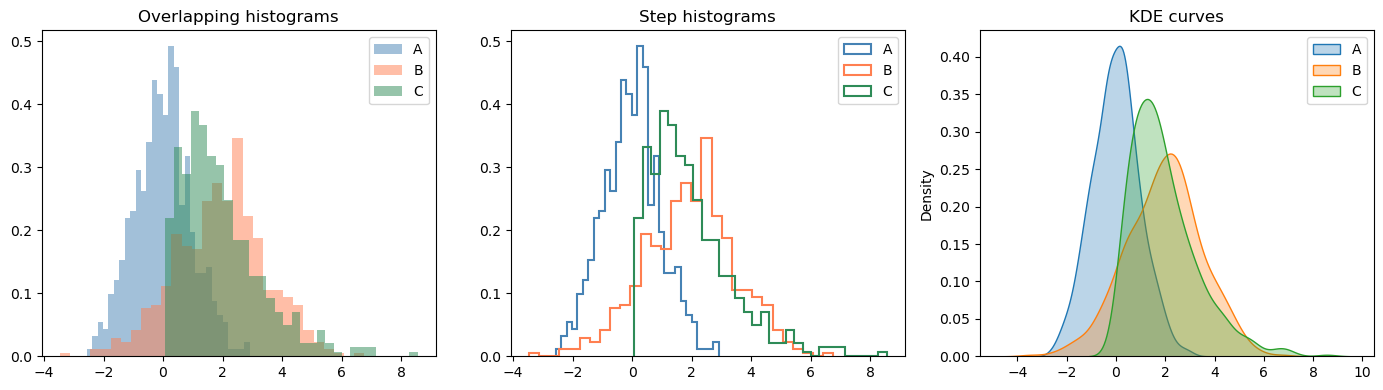

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)
a = rng.normal(0, 1, 500)
b = rng.normal(2, 1.5, 500)
c = rng.gamma(2, 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Option 1: Overlapping histograms with alpha ---
ax = axes[0]
for data, label, color in zip([a, b, c], ['A', 'B', 'C'], ['steelblue', 'coral', 'seagreen']):
    ax.hist(data, bins=30, alpha=0.5, label=label, color=color, density=True)
ax.set_title('Overlapping histograms')
ax.legend()

# --- Option 2: Step histograms ---
ax = axes[1]
for data, label, color in zip([a, b, c], ['A', 'B', 'C'], ['steelblue', 'coral', 'seagreen']):
    ax.hist(data, bins=30, histtype='step', label=label, color=color, density=True, linewidth=1.5)
ax.set_title('Step histograms')
ax.legend()

# --- Option 3: KDE curves ---
ax = axes[2]
for data, label in zip([a, b, c], ['A', 'B', 'C']):
    sns.kdeplot(data, ax=ax, label=label, fill=True, alpha=0.3)
ax.set_title('KDE curves')
ax.legend()

plt.tight_layout()
plt.show()